In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

In [2]:
%%fenicsx

"""
Using Compiled Forms in DOLFINx: Complete Example
==================================================

This script demonstrates the complete workflow from UFL forms to numerical
solutions using DOLFINx. It solves the Poisson equation with manufactured
solution and verifies convergence rates.

Author: FEniCS Workshop
Based on: https://jsdokken.com/FEniCS-workshop/

Usage:
    python dolfinx_poisson_solver.py
"""

import numpy as np
import scipy.sparse
import scipy.sparse.linalg
from mpi4py import MPI
import dolfinx
import dolfinx.fem
import dolfinx.mesh
import dolfinx.io
import basix.ufl
import ufl
import matplotlib.pyplot as plt


# ============================================================================
# Problem Definition
# ============================================================================

def u_exact(module, x):
    """
    Exact solution that works with both UFL and NumPy.

    u_ex(x,y) = sin(π/2 * x) * cos(π * y)
    """
    return module.sin(module.pi / 2 * x[0]) * module.cos(module.pi * x[1])


print("="*70)
print(" POISSON EQUATION SOLVER WITH MANUFACTURED SOLUTION")
print("="*70)
print("\nProblem: -∇²u = f in Ω = [0,1]²")
print("         u = g on ∂Ω")
print("\nManufactured solution: u_ex = sin(π/2 * x) * cos(π * y)")
print()


# ============================================================================
# UFL Formulation
# ============================================================================

print("Step 1: UFL Formulation")
print("-" * 70)

# Create abstract domain
c_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(2,))
domain = ufl.Mesh(c_el)

# Spatial coordinate
x = ufl.SpatialCoordinate(domain)

# Exact solution in UFL
u_ex = u_exact(ufl, x)

# Derive source term: f = -∇²u_ex
f = -ufl.div(ufl.grad(u_ex))

print("✓ Exact solution (UFL): ", u_ex)
print("✓ Source term (UFL): ", f)

# Define function space and variational form
el = basix.ufl.element("Lagrange", "triangle", 2)  # P2 elements
V = ufl.FunctionSpace(domain, el)

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Complete variational form
F = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx - ufl.inner(f, v) * ufl.dx

# Split into bilinear and linear forms
a, L = ufl.system(F)

print(f"✓ Bilinear form (a): contains TrialFunction and TestFunction")
print(f"✓ Linear form (L): contains TestFunction only")

# Define coefficient for numerical solution
uh = ufl.Coefficient(V)

# L² error form: ∫(uh - u_ex)² dx
error = ufl.inner(uh - u_ex, uh - u_ex) * ufl.dx

print("✓ Error form defined: L² = ∫(u_h - u_ex)² dx")
print()


# ============================================================================
# Create Mesh
# ============================================================================

print("Step 2: Create Mesh")
print("-" * 70)

Nx, Ny = 16, 16
mesh = dolfinx.mesh.create_unit_square(
    MPI.COMM_WORLD,
    Nx, Ny,
    cell_type=dolfinx.mesh.CellType.triangle
)

print(f"✓ Mesh created: {Nx} × {Ny} grid")
print(f"  Number of cells: {mesh.topology.index_map(mesh.topology.dim).size_local}")
print(f"  Number of vertices: {mesh.topology.index_map(0).size_local}")
print()


# ============================================================================
# Function Space
# ============================================================================

print("Step 3: Function Space")
print("-" * 70)

# Create function space from UFL element
V_dolfinx = dolfinx.fem.functionspace(mesh, el)

# Create function to hold solution
x_h = dolfinx.fem.Function(V_dolfinx)
x_h.name = "u_h"

print(f"✓ Function space created with P2 Lagrange elements")
print(f"  Number of DOFs: {V_dolfinx.dofmap.index_map.size_local}")
print(f"  Solution array shape: {x_h.x.array.shape}")
print()


# ============================================================================
# Boundary Conditions
# ============================================================================

print("Step 4: Boundary Conditions")
print("-" * 70)

# Interpolate exact solution for BC
gh = dolfinx.fem.Function(V_dolfinx)
gh.name = "g"
gh.interpolate(lambda x: u_exact(np, x))

print(f"✓ Boundary condition function interpolated")
print(f"  Min value: {gh.x.array.min():.6f}")
print(f"  Max value: {gh.x.array.max():.6f}")

# Find boundary facets
mesh.topology.create_entities(mesh.topology.dim - 1)
mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
boundary_facets = dolfinx.mesh.exterior_facet_indices(mesh.topology)

print(f"✓ Topology created")
print(f"  Number of boundary facets: {len(boundary_facets)}")

# Verify exterior facets (optional check)
facet_to_cell = mesh.topology.connectivity(mesh.topology.dim - 1, mesh.topology.dim)
num_single_cell_facets = sum(1 for facet in boundary_facets
                              if len(facet_to_cell.links(facet)) == 1)
print(f"  Boundary facets connected to 1 cell: {num_single_cell_facets}/{len(boundary_facets)}")

# Locate DOFs on boundary
boundary_dofs = dolfinx.fem.locate_dofs_topological(
    V_dolfinx,
    mesh.topology.dim - 1,
    boundary_facets
)

# Create Dirichlet BC
bc = dolfinx.fem.dirichletbc(gh, boundary_dofs)
bcs = [bc]

print(f"✓ Boundary conditions created")
print(f"  Number of constrained DOFs: {len(boundary_dofs)}")
print(f"  Percentage constrained: {100*len(boundary_dofs)/V_dolfinx.dofmap.index_map.size_local:.1f}%")
print()


# ============================================================================
# Compile Forms
# ============================================================================

print("Step 5: Compile Forms")
print("-" * 70)

# Compile forms
a_compiled = dolfinx.fem.compile_form(MPI.COMM_WORLD, a)
L_compiled = dolfinx.fem.compile_form(MPI.COMM_WORLD, L)
error_compiled = dolfinx.fem.compile_form(MPI.COMM_WORLD, error)

print("✓ Forms compiled to C code")
print("  - Bilinear form (a): Compiled ✓")
print("  - Linear form (L): Compiled ✓")
print("  - Error form: Compiled ✓")

# Create forms with mesh and function spaces
bilinear_form = dolfinx.fem.create_form(
    a_compiled, [V_dolfinx, V_dolfinx], mesh, {}, {}, {}
)
linear_form = dolfinx.fem.create_form(
    L_compiled, [V_dolfinx], mesh, {}, {}, {}
)

print("✓ Forms created with mesh data")
print()


# ============================================================================
# Assembly
# ============================================================================

print("Step 6: Assembly")
print("-" * 70)

# Create matrix and vector
A = dolfinx.fem.create_matrix(bilinear_form)
b = dolfinx.fem.create_vector(linear_form.function_spaces[0])

print(f"✓ Matrix and vector created")
print(f"  Matrix shape: {A.to_scipy().shape}")
print(f"  Vector shape: {b.array.shape}")

# Assemble matrix
dolfinx.fem.assemble_matrix(A, bilinear_form, bcs=bcs)
A.scatter_reverse()

A_scipy = A.to_scipy()

print(f"✓ Matrix assembled")
print(f"  Non-zero entries: {A_scipy.nnz:,}")
print(f"  Sparsity: {100 * A_scipy.nnz / (A_scipy.shape[0] * A_scipy.shape[1]):.2f}%")

# Assemble vector
dolfinx.fem.assemble_vector(b.array, linear_form)

# Apply boundary conditions
dolfinx.fem.apply_lifting(b.array, [bilinear_form], [bcs])
b.scatter_reverse(dolfinx.la.InsertMode.add)
[bc.set(b.array) for bc in bcs]

print(f"✓ Vector assembled with BCs applied")
print(f"  RHS norm: {np.linalg.norm(b.array):.6e}")
print()


# ============================================================================
# Solve
# ============================================================================

print("Step 7: Solve Linear System")
print("-" * 70)

# LU factorization
print("⚙  Computing LU factorization...")
A_inv = scipy.sparse.linalg.splu(A_scipy)

# Solve
x_h.x.array[:] = A_inv.solve(b.array)

print("✓ System solved!")
print(f"  Solution min: {x_h.x.array.min():.6f}")
print(f"  Solution max: {x_h.x.array.max():.6f}")
print()


# ============================================================================
# Error Estimation
# ============================================================================

print("Step 8: Error Estimation")
print("-" * 70)

# Create error form with solution
L2_error_form = dolfinx.fem.create_form(
    error_compiled, [], mesh, {}, {uh: x_h}, {}
)

# Assemble error
error_local = dolfinx.fem.assemble_scalar(L2_error_form)
error_global = mesh.comm.allreduce(error_local, op=MPI.SUM)
L2_error = np.sqrt(error_global)

print(f"✓ Error computed")
print(f"  L² error: {L2_error:.6e}")
print(f"  Relative error: {L2_error/np.sqrt(np.sum(gh.x.array**2)):.6e}")
print()


# ============================================================================
# Save Solution for ParaView
# ============================================================================

print("Step 9: Save Solution for ParaView")
print("-" * 70)

# Create VTK file for ParaView visualization
vtk_file = dolfinx.io.VTKFile(MPI.COMM_WORLD, "solution.pvd", "w")
vtk_file.write_function(x_h)
vtk_file.close()

print("✓ Solution saved to 'solution.pvd'")
print("  Open this file in ParaView to visualize the solution")

# Also save boundary condition for comparison
vtk_file_bc = dolfinx.io.VTKFile(MPI.COMM_WORLD, "exact_solution.pvd", "w")
vtk_file_bc.write_function(gh)
vtk_file_bc.close()

print("✓ Exact solution saved to 'exact_solution.pvd'")
print()


# ============================================================================
# Convergence Study
# ============================================================================

print("Step 10: Convergence Study")
print("-" * 70)


def solve_problem(N):
    """Solve the problem on an N×N mesh and return the L² error."""

    # Create mesh
    mesh = dolfinx.mesh.create_unit_square(
        MPI.COMM_WORLD, N, N, cell_type=dolfinx.mesh.CellType.triangle
    )

    # Function space
    V = dolfinx.fem.functionspace(mesh, el)
    x = dolfinx.fem.Function(V)

    # Boundary conditions
    gh = dolfinx.fem.Function(V)
    gh.interpolate(lambda x: u_exact(np, x))

    mesh.topology.create_entities(mesh.topology.dim - 1)
    mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
    boundary_facets = dolfinx.mesh.exterior_facet_indices(mesh.topology)
    boundary_dofs = dolfinx.fem.locate_dofs_topological(
        V, mesh.topology.dim - 1, boundary_facets
    )
    bc = dolfinx.fem.dirichletbc(gh, boundary_dofs)
    bcs = [bc]

    # Assembly
    bilinear_form = dolfinx.fem.create_form(a_compiled, [V, V], mesh, {}, {}, {})
    linear_form = dolfinx.fem.create_form(L_compiled, [V], mesh, {}, {}, {})

    A = dolfinx.fem.create_matrix(bilinear_form)
    b = dolfinx.fem.create_vector(linear_form.function_spaces[0])

    dolfinx.fem.assemble_matrix(A, bilinear_form, bcs=bcs)
    A.scatter_reverse()

    dolfinx.fem.assemble_vector(b.array, linear_form)
    dolfinx.fem.apply_lifting(b.array, [bilinear_form], [bcs])
    b.scatter_reverse(dolfinx.la.InsertMode.add)
    [bc.set(b.array) for bc in bcs]

    # Solve
    A_scipy = A.to_scipy()
    A_inv = scipy.sparse.linalg.splu(A_scipy)
    x.x.array[:] = A_inv.solve(b.array)

    # Error
    L2_error_form = dolfinx.fem.create_form(
        error_compiled, [], mesh, {}, {uh: x}, {}
    )
    error_local = dolfinx.fem.assemble_scalar(L2_error_form)
    error_global = mesh.comm.allreduce(error_local, op=MPI.SUM)

    return np.sqrt(error_global)


# Run convergence study
Ns = np.array([8, 16, 32, 64])
hs = 1.0 / Ns
errors = np.zeros_like(Ns, dtype=np.float64)

print("⚙  Running convergence study...\n")
for i, N in enumerate(Ns):
    print(f"  Solving on {N}×{N} mesh...", end=" ")
    errors[i] = solve_problem(N)
    print(f"Error = {errors[i]:.6e}")

print("\n✓ Convergence study complete")
print()


# ============================================================================
# Compute Convergence Rates
# ============================================================================

print("Step 11: Convergence Results")
print("-" * 70)

# Compute convergence rates
rates = np.log(errors[1:] / errors[:-1]) / np.log(hs[1:] / hs[:-1])

print()
print("="*70)
print(" CONVERGENCE RESULTS")
print("="*70)
print(f"\n{'N':<8} {'h':<12} {'Error':<15} {'Rate':<8}")
print("-"*70)
for i, N in enumerate(Ns):
    h = hs[i]
    err = errors[i]
    if i == 0:
        print(f"{N:<8} {h:<12.6f} {err:<15.6e} {'—':<8}")
    else:
        print(f"{N:<8} {h:<12.6f} {err:<15.6e} {rates[i-1]:<8.2f}")

print("\n" + "="*70)
print(f"Expected rate for P2 elements: 3.0")
print(f"Average observed rate: {rates.mean():.2f}")
print("="*70)
print()


# ============================================================================
# Plot Convergence
# ============================================================================

print("Step 12: Generate Convergence Plot")
print("-" * 70)

plt.figure(figsize=(10, 6))
plt.loglog(hs, errors, 'o-', linewidth=2, markersize=8, label='Computed error')
plt.loglog(hs, errors[0] * (hs/hs[0])**3, '--', linewidth=2, label='O(h³) reference')
plt.xlabel('Mesh size h', fontsize=12)
plt.ylabel('L² Error', fontsize=12)
plt.title('Convergence Study for P2 Elements', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150, bbox_inches='tight')
print("✓ Convergence plot saved to 'convergence_plot.png'")
print()


# ============================================================================
# Summary
# ============================================================================

print("="*70)
print(" SUMMARY")
print("="*70)
print()
print("✓ Poisson equation solved with manufactured solution")
print("✓ P2 Lagrange elements used")
print(f"✓ L² error: {L2_error:.6e}")
print(f"✓ Convergence rate: {rates.mean():.2f} (expected: 3.0)")
print()
print("Generated files:")
print("  - solution.pvd (numerical solution for ParaView)")
print("  - exact_solution.pvd (exact solution for ParaView)")
print("  - convergence_plot.png (convergence graph)")
print()
print("To visualize in ParaView:")
print("  1. Open ParaView")
print("  2. File → Open → solution.pvd")
print("  3. Click 'Apply' in the Properties panel")
print("  4. Select 'u_h' in the coloring dropdown")
print()
print("="*70)
print(" EXECUTION COMPLETE")
print("="*70)

 POISSON EQUATION SOLVER WITH MANUFACTURED SOLUTION

Problem: -∇²u = f in Ω = [0,1]²
         u = g on ∂Ω

Manufactured solution: u_ex = sin(π/2 * x) * cos(π * y)

Step 1: UFL Formulation
----------------------------------------------------------------------
✓ Exact solution (UFL):  cos(3.141592653589793 * x[1]) * sin(1.5707963267948966 * x[0])
✓ Source term (UFL):  -1 * (div(grad(cos(3.141592653589793 * x[1]) * sin(1.5707963267948966 * x[0]))))
✓ Bilinear form (a): contains TrialFunction and TestFunction
✓ Linear form (L): contains TestFunction only
✓ Error form defined: L² = ∫(u_h - u_ex)² dx

Step 2: Create Mesh
----------------------------------------------------------------------
✓ Mesh created: 16 × 16 grid
  Number of cells: 512
  Number of vertices: 289

Step 3: Function Space
----------------------------------------------------------------------
✓ Function space created with P2 Lagrange elements
  Number of DOFs: 1089
  Solution array shape: (1089,)

Step 4: Boundary Condition

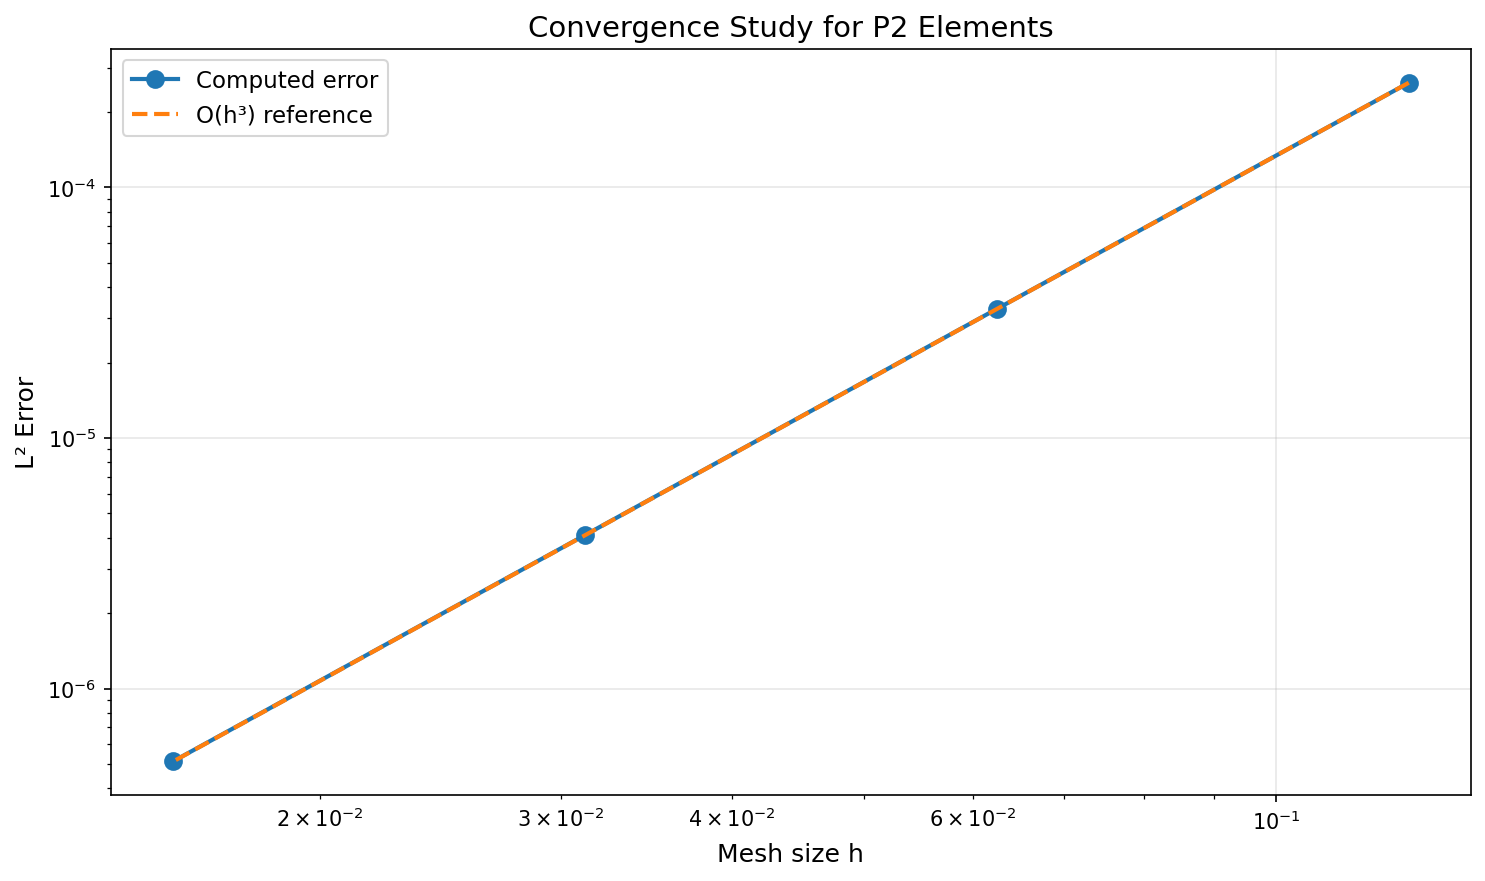

In [3]:
from IPython.display import Image, display

display(Image("convergence_plot.png"))

In [4]:
import glob
import zipfile
from google.colab import files

file_list = glob.glob("solution*.*")

zip_name = "solutions.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in file_list:
        zf.write(f)

files.download(zip_name)

file_list = glob.glob("exact_solution*.*")

zip_name = "exact_solutions.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in file_list:
        zf.write(f)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>